
# Interactive playground for possession preprocessing.

This file mirrors the flow from `tests/test_preprocessing.py`, but in a PyCharm-friendly
'Python Scientific' format using `#%%` cells.

Run it cell-by-cell to quickly iterate on preprocessing, feature engineering, and visualization.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import socceraction.spadl as spadl
from socceraction.xthreat import load_model

project_root = Path().resolve().parent.parent
sys.path.insert(0, str(project_root))

from src.analysis.visualization import plot_possession_actions
from src.data.data_loader import load_statsbomb_socceraction_data
from src.ml.preprocessing.sequence import SequencePreprocessor

pd.set_option('display.width', 1000)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)


In [2]:
SEQUENCE_LENGTH = 6
MINIMUM_SEQUENCE_LENGTH = 3
DATA_PATH = "../../data/statsbomb/data"
COMPETITION_ID = 55
SEASON_ID = 282


In [3]:
sample_game = next(load_statsbomb_socceraction_data(DATA_PATH, COMPETITION_ID, SEASON_ID))
match, events = sample_game

print("events:", len(events))
print("match_id:", match.get("game_id", match.name))
print("home_team_id:", match.get("home_team_id"))


Found 51 matches in competition 55, season 282
Loading events for match 3942819 (1/51)...
events: 3485
match_id: 3942819
home_team_id: 941


In [4]:
preprocessor = SequencePreprocessor(sequence_length=SEQUENCE_LENGTH,
                                    minimum_sequence_length=MINIMUM_SEQUENCE_LENGTH,
                                    xt_model=load_model("../../models/xt_models/default_xt_model.json"))


In [5]:
actions_by_possession = preprocessor._extract_actions(match, events)
print("possession count (len>=SEQUENCE_LENGTH):", len(actions_by_possession))
keys_ = list(actions_by_possession.keys())
print("first 10 possession ids:", keys_[:10])
for possession_id in keys_:
    print(f"possession: {possession_id} length: {len(actions_by_possession[possession_id])}")


possession count (len>=SEQUENCE_LENGTH): 97
first 10 possession ids: [2, 4, 5, 6, 7, 8, 9, 10, 11, 12]
possession: 2 length: 7
possession: 4 length: 23
possession: 5 length: 59
possession: 6 length: 10
possession: 7 length: 16
possession: 8 length: 22
possession: 9 length: 23
possession: 10 length: 26
possession: 11 length: 20
possession: 12 length: 27
possession: 13 length: 6
possession: 14 length: 4
possession: 16 length: 10
possession: 17 length: 12
possession: 18 length: 34
possession: 22 length: 13
possession: 23 length: 15
possession: 24 length: 40
possession: 25 length: 4
possession: 26 length: 6
possession: 27 length: 19
possession: 28 length: 19
possession: 30 length: 56
possession: 31 length: 29
possession: 32 length: 36
possession: 33 length: 22
possession: 34 length: 6
possession: 36 length: 61
possession: 37 length: 3
possession: 38 length: 28
possession: 39 length: 3
possession: 40 length: 34
possession: 41 length: 5
possession: 42 length: 61
possession: 44 length: 15
pos

In [6]:
pid = 37  # change me
possession_df = actions_by_possession[pid]
print("len:", len(possession_df))
print("columns:", len(possession_df.columns))
print(possession_df.head(10))


len: 3
columns: 24
     game_id                     original_event_id  period_id  time_seconds  team_id  player_id  start_x  start_y     end_x    end_y  type_id  result_id  bodypart_id  action_id    team_name      player_name  possession type_name  duration  under_pressure  counterpress   xG  possession_team_id possession_team_name
635  3942819  024d8307-f708-4a74-8e50-efb60b440bf7          1      1916.797      941     3669.0  5.64375  39.5675   4.33125  30.5575       22          1            4        635  Netherlands  Virgil van Dijk          37      Pass  1.693634           False         False  0.0                 941          Netherlands
636  3942819  ac27da95-3919-4631-b1c5-13bc8c21921c          1      1918.491      941    37274.0  4.33125  30.5575   5.90625  25.7125       21          1            0        636  Netherlands  Bart Verbruggen          37     Carry  2.027401           False         False  0.0                 941          Netherlands
637  3942819  820284b5-a099-4026-904

In [7]:
possession_feat = preprocessor._update_action(possession_df.copy())
print("len:", len(possession_feat))
print("columns:", len(possession_feat.columns))
print(possession_feat)


len: 3
columns: 31
     game_id                     original_event_id  period_id  time_seconds  team_id  player_id  start_x  start_y     end_x    end_y  type_id  result_id  bodypart_id  action_id    team_name      player_name  possession type_name  duration  under_pressure  counterpress   xG  possession_team_id possession_team_name        xT       dx      dy   distance     angle  time_diff  opposite_action
635  3942819  024d8307-f708-4a74-8e50-efb60b440bf7          1      1916.797      941     3669.0  5.64375  39.5675   4.33125  30.5575       22          1            4        635  Netherlands  Virgil van Dijk          37      Pass  1.693634           False         False  0.0                 941          Netherlands  0.009411  -1.3125  -9.010   9.105095 -1.715450      0.000                0
636  3942819  ac27da95-3919-4631-b1c5-13bc8c21921c          1      1918.491      941    37274.0  4.33125  30.5575   5.90625  25.7125       21          1            0        636  Netherlands  Bart Ver

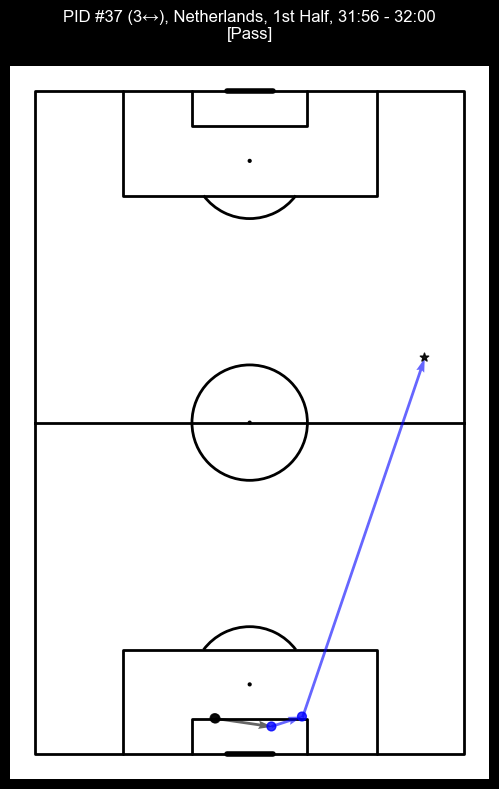

In [8]:
viz = spadl.add_names(possession_feat)
viz["team_name"] = np.where(viz["team_id"] == 941, "Netherlands", "England")
viz["possession"] = pid

fig = plot_possession_actions(viz)
plt.show()


In [9]:
norm = preprocessor._normalize_features(possession_feat)
print("normalized shape:", norm.shape)

seq = preprocessor._create_simple_sequence(norm)
print("sequence shape:", seq.shape)

normalized shape: (3, 46)
sequence shape: (1, 6, 46)


In [10]:
print("sequence data:", seq)

sequence data: [[[ 0.05375     0.581875    0.04125     0.449375    0.08671519
   -0.98955584 -0.14415006  0.          0.          0.
    0.          0.          0.          0.          0.
    0.          0.          0.          0.          0.
    0.          0.          0.          0.          0.
    0.          0.          0.          0.          0.
    0.          0.          0.          1.          0.
    1.          0.          0.          0.          0.
    0.          0.          0.          0.          1.
    0.        ]
  [ 0.04125     0.449375    0.05625     0.378125    0.04851972
   -0.95101243  0.30915263  0.1694      0.          0.
    0.          0.          0.          0.          0.
    0.          0.          0.          0.          0.
    0.          0.          0.          0.          0.
    0.          0.          0.          0.          0.
    0.          0.          1.          0.          0.
    1.          0.          0.          0.          0.
    1.          0.

In [11]:
last = possession_feat.tail(SEQUENCE_LENGTH)
label = preprocessor._create_label(last)
print("xG sum:", last["xG"].sum())
print("xT sum:", last["xT"].sum())
print("label:", label)


xG sum: 0.0
xT sum: 0.03627172
label: 0.0174506


In [12]:
match_id = match.get("game_id", match.name)
X, y, p = preprocessor.process_match(match_id, match, events)
print("X:", X.shape, "y:", y.shape, "p:", p.shape)
print("sample y[0], y[8], y[12]:", y[0], y[8], y[12])


→Processing match 3942819: 3485 events (mode: training)
 → Generated 1657 sequences, 1657 labels for match 3942819
X: (1657, 6, 46) y: (1657,) p: (1657,)
sample y[0], y[8], y[12]: 0.02385149 0.00942382 0.00878589
